### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
#Review the first few rows to get an idea about the data

data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [4]:
#some columns are not showing; so using transpose option to see all columns' values
data.head(5).T

,0,1,2,3,4
destination,No Urgent Place,No Urgent Place,No Urgent Place,No Urgent Place,No Urgent Place
passanger,Alone,Friend(s),Friend(s),Friend(s),Friend(s)
weather,Sunny,Sunny,Sunny,Sunny,Sunny
temperature,55,80,80,80,80
time,2PM,10AM,10AM,2PM,2PM
coupon,Restaurant(<20),Coffee House,Carry out & Take away,Coffee House,Coffee House
expiration,1d,2h,2h,2h,1d
gender,Female,Female,Female,Female,Female
age,21,21,21,21,21
maritalStatus,Unmarried partner,Unmarried partner,Unmarried partner,Unmarried partner,Unmarried partner


In [5]:
#just curious to explore the data without transpose. So searched on pandas guide online to display all columns

pd.set_option('display.max_columns', None)
data.head(5)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [6]:
#Check for the data types are all variables in the dataframe
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [7]:
#counting the number of missing values across all columns
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [8]:
#Looks like of the total 12,684 offers in the dataframe, most of them have missing value for Car. 
#But, I want to get % of missing to make sure I get an objective data
missing = (data.isnull().sum() / len(data)) * 100
missing

destination              0.000000
passanger                0.000000
weather                  0.000000
temperature              0.000000
time                     0.000000
coupon                   0.000000
expiration               0.000000
gender                   0.000000
age                      0.000000
maritalStatus            0.000000
has_children             0.000000
education                0.000000
occupation               0.000000
income                   0.000000
car                     99.148534
Bar                      0.843582
CoffeeHouse              1.710817
CarryAway                1.190476
RestaurantLessThan20     1.024913
Restaurant20To50         1.490066
toCoupon_GEQ5min         0.000000
toCoupon_GEQ15min        0.000000
toCoupon_GEQ25min        0.000000
direction_same           0.000000
direction_opp            0.000000
Y                        0.000000
dtype: float64

In [9]:
# Filter for rows where the columns identified to have missing values, are actually populated with values
# Helps to get a visual of how the data looks for these variables when it is not missing

cols = [
    "car",
    "Bar",
    "CoffeeHouse",
    "CarryAway",
    "RestaurantLessThan20",
    "Restaurant20To50"
]

data[data[cols].notnull().all(axis=1)].head(5)
    

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1237,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,26,Single,0,Graduate degree (Masters or Doctorate),Sales & Related,$12500 - $24999,Scooter and motorcycle,less1,4~8,4~8,1~3,never,1,0,0,0,1,1
1238,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,26,Single,0,Graduate degree (Masters or Doctorate),Sales & Related,$12500 - $24999,Scooter and motorcycle,less1,4~8,4~8,1~3,never,1,0,0,0,1,0
1239,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,26,Single,0,Graduate degree (Masters or Doctorate),Sales & Related,$12500 - $24999,Scooter and motorcycle,less1,4~8,4~8,1~3,never,1,0,0,0,1,1
1240,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,26,Single,0,Graduate degree (Masters or Doctorate),Sales & Related,$12500 - $24999,Scooter and motorcycle,less1,4~8,4~8,1~3,never,1,1,0,0,1,0
1241,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,26,Single,0,Graduate degree (Masters or Doctorate),Sales & Related,$12500 - $24999,Scooter and motorcycle,less1,4~8,4~8,1~3,never,1,0,0,0,1,1


3. Decide what to do about your missing data -- drop, replace, other...

In [10]:
#Dropping the column "car" because as the above analysis shows >99% of its values are NaN

data = data.drop(columns=["car"])


In [11]:
# I would like to get the frequency counts of these variables which has null values to see what other values it takes to decide on transformation

cols = [
    "Bar",
    "CoffeeHouse",
    "CarryAway",
    "RestaurantLessThan20",
    "Restaurant20To50"
]

for col in cols:
    print(data[col].value_counts(dropna=False))

    

Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64
CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
NaN       217
Name: count, dtype: int64
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
NaN       151
Name: count, dtype: int64
RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
NaN       130
Name: count, dtype: int64
Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
NaN       189
Name: count, dtype: int64


In [12]:
#Before deciding on what treatment to choose for these variables, checking the missing values freqency against Y
#Searching online learnt about the crosstab function and hence using that

cols = [
    "Bar",
    "CoffeeHouse",
    "CarryAway",
    "RestaurantLessThan20",
    "Restaurant20To50"
]

for col in cols:
    data_subset = data[data[col].isnull()]
    print(pd.crosstab(data_subset[col].isnull(), data_subset["Y"], normalize="index"))


Y            0         1
Bar                     
True  0.485981  0.514019
Y                   0         1
CoffeeHouse                    
True         0.493088  0.506912
Y                 0         1
CarryAway                    
True       0.331126  0.668874
Y                            0         1
RestaurantLessThan20                    
True                  0.315385  0.684615
Y                        0         1
Restaurant20To50                    
True              0.444444  0.555556


In [13]:
# Given the above analysis, which shows that the response (i.e. Y = 1 or 0) is Bar, Coffeehouse and Restaurant20to50
# (cont) are pretty equally distributed, decided to drop the offers when these variables are missing (no major loss in response data)

cols1 = [
    "Bar",
    "CoffeeHouse",
    "Restaurant20To50"
]

data1 = data.dropna(subset=cols1)

print("Before:", data.shape)
print("After :", data1.shape)


Before: (12684, 25)
After : (12276, 25)


In [14]:
#For the remaining two variables CarryAway and RestaurantLessThan20, setting the value wherever missing to 'never'
# (cont) because it is highly likely there was no carryaway option or no restaurant with <$20.

cols2 = [
    "CarryAway",
    "RestaurantLessThan20"
]

data1[cols2] = data1[cols2].fillna("never")


/var/folders/66/gkn4d18164jggs19kr7fl86c0000gn/T/ipykernel_27709/116201255.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1[cols2] = data1[cols2].fillna("never")


In [15]:
data1.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

4. What proportion of the total observations chose to accept the coupon?



In [22]:
data1.head(5).T

,0,1,2,3,4
destination,No Urgent Place,No Urgent Place,No Urgent Place,No Urgent Place,No Urgent Place
passanger,Alone,Friend(s),Friend(s),Friend(s),Friend(s)
weather,Sunny,Sunny,Sunny,Sunny,Sunny
temperature,55,80,80,80,80
time,2PM,10AM,10AM,2PM,2PM
coupon,Restaurant(<20),Coffee House,Carry out & Take away,Coffee House,Coffee House
expiration,1d,2h,2h,2h,1d
gender,Female,Female,Female,Female,Female
age,21,21,21,21,21
maritalStatus,Unmarried partner,Unmarried partner,Unmarried partner,Unmarried partner,Unmarried partner


In [21]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12276 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12276 non-null  object
 1   passanger             12276 non-null  object
 2   weather               12276 non-null  object
 3   temperature           12276 non-null  int64 
 4   time                  12276 non-null  object
 5   coupon                12276 non-null  object
 6   expiration            12276 non-null  object
 7   gender                12276 non-null  object
 8   age                   12276 non-null  object
 9   maritalStatus         12276 non-null  object
 10  has_children          12276 non-null  int64 
 11  education             12276 non-null  object
 12  occupation            12276 non-null  object
 13  income                12276 non-null  object
 14  Bar                   12276 non-null  object
 15  CoffeeHouse           12276 non-null  obj

In [23]:
#Given that Y is an int64 and also takes values 0 or 1, instead of doing the standard way of calculating sum where Y is 1 
#and then dividing by total observations, I chose to use mean() function as it is one line code and gives same result

data1["Y"].mean()


np.float64(0.5709514499837081)

# Ans: 57.1% of the observations accepted the coupon #

5. Use a bar plot to visualize the `coupon` column.

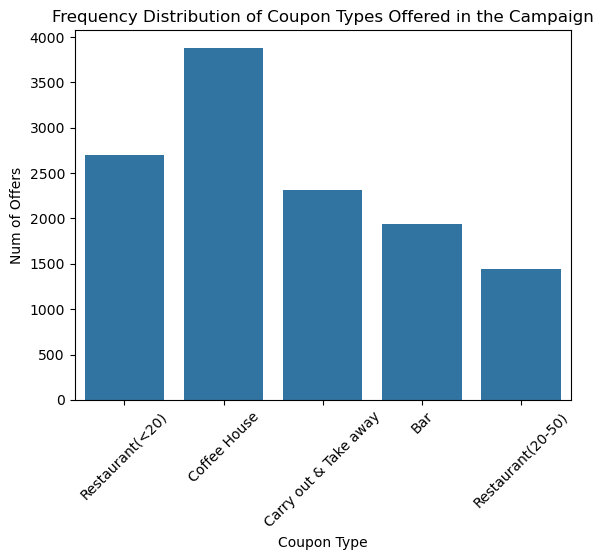

In [24]:
# Seaborn ploting option might be useful for understanding the frequency count of various type of coupons offered

sns.countplot(
    data=data1,
    x="coupon"
)

plt.title("Frequency Distribution of Coupon Types Offered in the Campaign")
plt.xlabel("Coupon Type")
plt.ylabel("Num of Offers")
plt.xticks(rotation=45)

plt.show()


# Looking at the counts of coupon, it seems they rank in the following order: Coffee House, Restaurants that cost < "20" Carry out/Take away, Bar and finally restaurants that are $20-$50 on descending order. #

6. Use a histogram to visualize the temperature column.

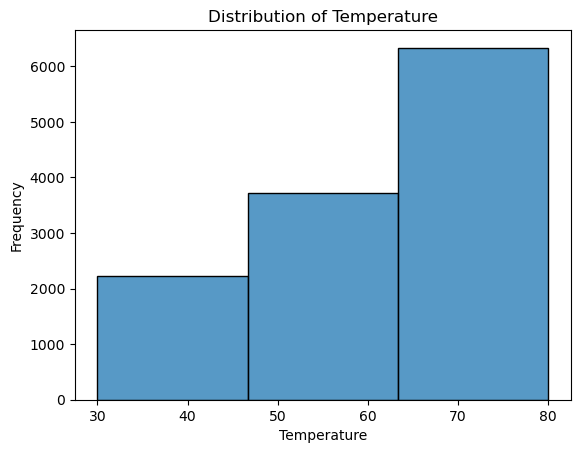

In [29]:
# using Seaborn histplot to visualoze the temperature column. Trying 5 bins first to see how it looks and then adjust number of bins

sns.histplot(data1["temperature"], bins=3)
# adjusted the bins to be 3 after iterations as it made more sense

plt.title("Distribution of Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()


# Looks like most of the offere where made during high temperature situation

# This intrigued me to look at relationship between coupons and temperature because I am wondering if there is more offers 
# (contd) at Coffee Houses because customers maybe looking for a quick hydrating drinks. Hence decided to look at both variables together

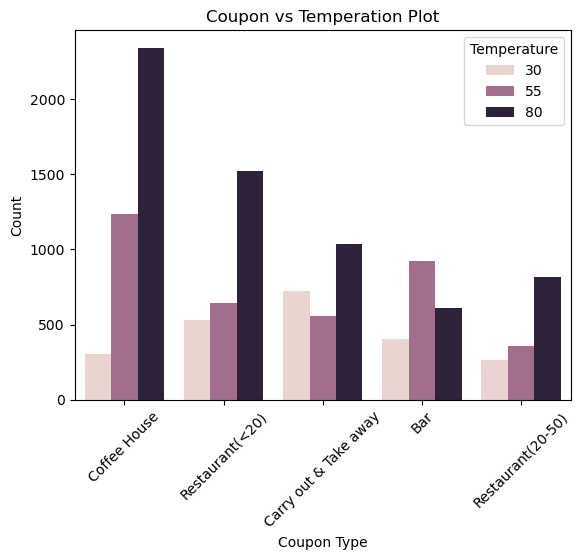

In [30]:
# Plotting coupon with temperature as hue to visualize the relationship

sns.countplot(
    data=data1,
    x="coupon",
    hue="temperature",
    order=data1["coupon"].value_counts().index
)

plt.title("Coupon vs Temperation Plot")
plt.xlabel("Coupon Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Temperature")

plt.show()


# Looks like Coffee House being the highest offered coupon and especially during higher temperature weather conditions

In [68]:
#filtering data1 to create a new dataframe data2 to retain "Bar" coupon observations only

data2 = data1[data1["coupon"] == "Bar"]

#running a frequency count check to make sure data filtering worked fine
data2["coupon"].value_counts()


coupon
Bar    1942
Name: count, dtype: int64

2. What proportion of bar coupons were accepted?


In [69]:
#There are two ways to do this

#Usual method: Given that Y which takes value 1 for acceptance and 0 for rejection, adding it up and diving my total will give the proportion
accepted = data2["Y"].sum()
total = len(data2)
prop_accepted = accepted/total

print("prop_accepted:", prop_accepted)

#alternate method: just using mean() will give same result
data2["Y"].mean()



prop_accepted: 0.41503604531410915


np.float64(0.41503604531410915)

# About 41.5% of the offered coupons where accepted by the drivers in the observations samples

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [71]:
#printing counts of values to get an idea of the values
data2["Bar"].value_counts()

Bar
never    801
less1    559
1~3      386
4~8      147
gt8       49
Name: count, dtype: int64

In [72]:
# Excluding the observations about customers who 'never' visited the bar to create dataframe bar_data
bar_data = data2[data2["Bar"] != "never"].copy()

#creating a small user defined function to check the value of "Bar" variable as an argument to assign bar_group as less than 3 visits or more
def bar_group(x):
    if x in ["less1", "1~3"]:
        return "≤3"
    elif x in ["4~8", "gt8"]:
        return ">3"
    else:
        return None

bar_data["Bar_group"] = bar_data["Bar"].apply(bar_group)

#using the groupby filtering option and mean() function to calculate the acceptance rate (Y variable)
bar_data.groupby("Bar_group")["Y"].mean()



Bar_group
>3    0.765306
≤3    0.530159
Name: Y, dtype: float64

# Among the customer who made at least 1 visit, Customers who made 3 or more visits are more likely to accept the offer at 76.5% offere acceptance compared to 53% acceptance rate by others who vist the bar

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


<Axes: xlabel='age', ylabel='Count'>

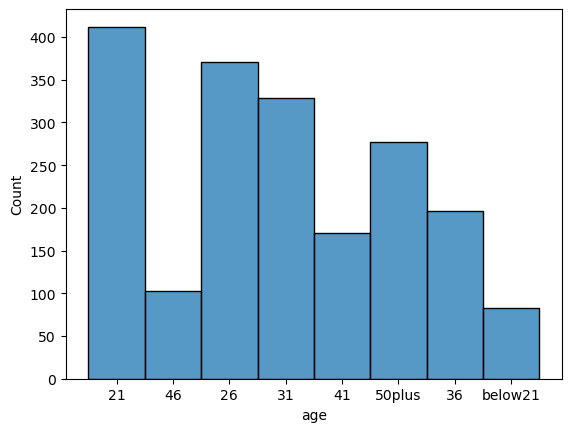

In [74]:
sns.histplot(data2["age"], bins=10)

In [75]:
# Using the value counts of age variable to understand the values
data2["age"].value_counts()

age
21         412
26         371
31         329
50plus     277
36         196
41         171
46         103
below21     83
Name: count, dtype: int64

group
Group1    0.690244
Group2    0.341384
Name: Y, dtype: float64


/var/folders/66/gkn4d18164jggs19kr7fl86c0000gn/T/ipykernel_27709/3237342732.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2["group"] = np.where(group1_mask, "Group1", "Group2")


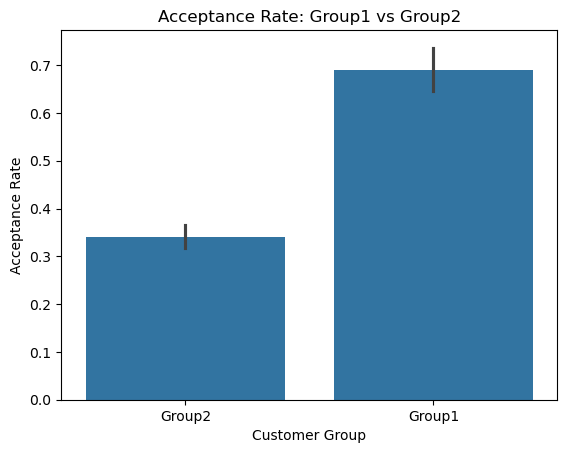

In [96]:
#Creating filter for the relevant bar visits
bar_filter = data2["Bar"].isin(["1~3", "4~8", "gt8"])

#Creating filter for the relevant aged drivers
age_filter = data2["age"].isin(["26", "31", "36", "41", "46", "50plus"])

#Filtering all drivers who meet the age and bar visit criteria in Group1 vs all others as Group2
group1_mask = bar_filter & age_filter
data2["group"] = np.where(group1_mask, "Group1", "Group2")

#calculating the acceptance rate by the two groups
print(data2.groupby("group")["Y"].mean())

sns.barplot(data=data2, x="group", y="Y")

plt.title("Acceptance Rate: Group1 vs Group2")
plt.ylabel("Acceptance Rate")
plt.xlabel("Customer Group")

plt.show()

# Looks like the drivers who made at least 1 bar visit and above 25, are likely to respond at 69% acceptance rate compared to almost half that chance with the rest of the drivers at a lower 34% acceptance rate among those who visits the bar


# ps: Analyzing the above warning message and searching online, I learnt that if I had used .copy to creaete dataframe data2, it would have been a better practice. Moving forward I will try to remember this

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [98]:
data3 = data1[data1["coupon"] == "Bar"].copy()
print(data3["passanger"].value_counts())
print(data3["occupation"].value_counts())


passanger
Alone        1159
Friend(s)     321
Partner       263
Kid(s)        199
Name: count, dtype: int64
occupation
Unemployed                                   298
Student                                      243
Computer & Mathematical                      225
Sales & Related                              175
Education&Training&Library                   128
Management                                   108
Office & Administrative Support              105
Arts Design Entertainment Sports & Media      91
Business & Financial                          82
Retired                                       71
Food Preparation & Serving Related            48
Healthcare Support                            44
Community & Social Services                   40
Healthcare Practitioners & Technical          36
Transportation & Material Moving              35
Legal                                         34
Architecture & Engineering                    27
Protective Service                            27

group2
Group1    0.715026
Group2    0.381933
Name: Y, dtype: float64


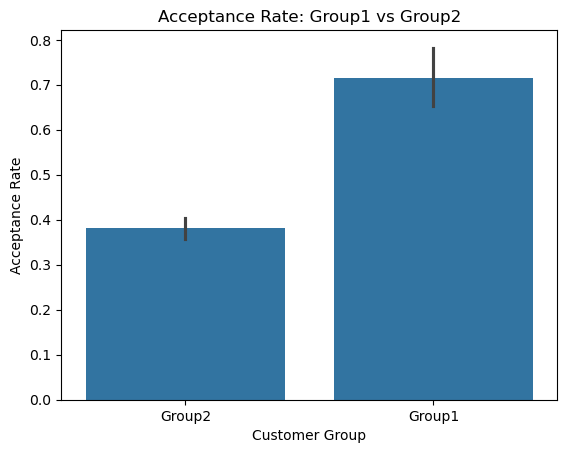

In [100]:
# Creating filter for the relevant bar visits
bar_filter = data3["Bar"].isin(["1~3", "4~8", "gt8"])

# Creating filter for the drivers who don't have kids as passengers
passanger_filter = data3["passanger"].isin(["Friend(s)", "Partner"])

# Creating filter for the drivers who are not working in farming, fishing or forestry
occupation_filter = data3["occupation"] != "Farming Fishing & Forestry"

# Combine all conditions
group2_ind = bar_filter & passanger_filter & occupation_filter

# Create group column
data3["group2"] = np.where(group2_ind, "Group1", "Group2")

# Acceptance rate by group
print(data3.groupby("group2")["Y"].mean())

sns.barplot(data=data3, x="group2", y="Y")

plt.title("Acceptance Rate: Group1 vs Group2")
plt.ylabel("Acceptance Rate")
plt.xlabel("Customer Group")

plt.show()

# The analysis shows that this identified group of drivers who has a passenger that is not a kid and also doesn't work in Farming,Fishing or Forestry industry, then they are more likely at 71.5% offer acceptance rate compared to everyone else who visits the bar

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [102]:
print(data3["maritalStatus"].value_counts())
print(data3["RestaurantLessThan20"].value_counts())
print(data3["income"].value_counts())


maritalStatus
Married partner      840
Single               645
Unmarried partner    367
Divorced              73
Widowed               17
Name: count, dtype: int64
RestaurantLessThan20
1~3      839
4~8      560
less1    315
gt8      186
never     42
Name: count, dtype: int64
income
$25000 - $37499     304
$100000 or More     282
$12500 - $24999     271
$50000 - $62499     255
$37500 - $49999     252
Less than $12500    164
$75000 - $87499     147
$87500 - $99999     138
$62500 - $74999     129
Name: count, dtype: int64


# Chose the following option: go to bars more than once a month, had passengers that were not a kid, and were not widowed

group3
Group1    0.715026
Group2    0.381933
Name: Y, dtype: float64


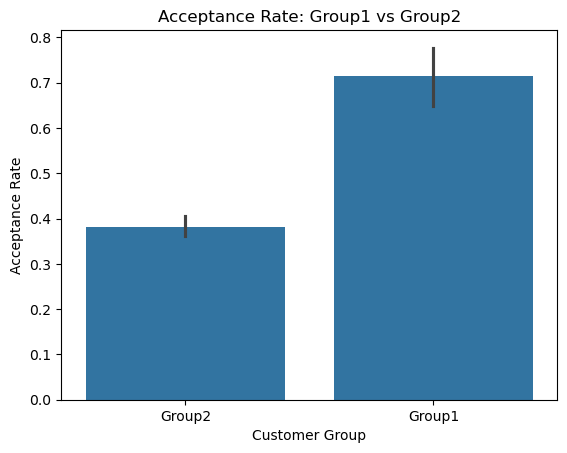

In [104]:
# Group 1 is go to bars more than once a month, had passengers that were not a kid,and were not widowed
# Group 2 everyone else who has got the bar coupon

# Creating filter for the relevant bar visits
bar_filter = data3["Bar"].isin(["1~3", "4~8", "gt8"])

# Creating filter for the drivers who don't have kids as passengers
passanger_filter = data3["passanger"].isin(["Friend(s)", "Partner"])

# Creating filter for the drivers who aren't widowed
m_status_notwidow = data3["maritalStatus"] != "Widowed"


# Combine all conditions
group3_ind = bar_filter & passanger_filter & m_status_notwidow

# Create group column
data3["group3"] = np.where(group3_ind, "Group1", "Group2")

# Acceptance rate by group
print(data3.groupby("group3")["Y"].mean())

sns.barplot(data=data3, x="group3", y="Y")

plt.title("Acceptance Rate: Group1 vs Group2")
plt.ylabel("Acceptance Rate")
plt.xlabel("Customer Group")

plt.show()

# The above analysis shows that group of drivers who visit the bar at least once a month, travel with a passanger who is not a kid and also is not a widow is likely to respond to the coupon at a higher acceptance rate of 71.5% compared to the rest of bar visiting drivers

# Also, the effect of excluding widowed customers from the analysis doesn't have much effect becuase the there only 17 (very small) customers who are widowed and are visiting bar at least once.


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

# Based on the above analysis, my hypothesis is that if a driver has made at least one bar visit, with a companion who is not a kid, and above age 26, there is a better chance they will accept the coupon offer than other groups that are visiting the bar

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

# Choosing to analyze the Coffee House Coupon group

In [105]:
#filtering data1 to create a new dataframe data2 to retain "Bar" coupon observations only

data4 = data1[data1["coupon"] == "Coffee House"].copy()

#running a frequency count check to make sure data filtering worked fine
data4["coupon"].value_counts()

coupon
Coffee House    3881
Name: count, dtype: int64

In [108]:
# I want to analyze how the following attrivutes behave for this customer segment: age, gender, temparature, destination and weather

cols = ["age", "gender", "temperature", "destination", "weather"]

for col in cols:
    print(data4[col].value_counts())

age
21         875
26         803
31         602
50plus     534
36         382
41         317
46         217
below21    151
Name: count, dtype: int64
gender
Female    2016
Male      1865
Name: count, dtype: int64
temperature
80    2340
55    1239
30     302
Name: count, dtype: int64
destination
No Urgent Place    2090
Home                901
Work                890
Name: count, dtype: int64
weather
Sunny    3377
Snowy     288
Rainy     216
Name: count, dtype: int64


In [109]:
# plotting a crosstab to see how the response rate (Y) behaves across these variables

for col in cols:
    print(f"\n===== {col} vs Y =====")
    print(pd.crosstab(data4[col], data4["Y"], normalize="index"))



===== age vs Y =====
Y               0         1
age                        
21       0.477714  0.522286
26       0.484433  0.515567
31       0.514950  0.485050
36       0.531414  0.468586
41       0.507886  0.492114
46       0.493088  0.506912
50plus   0.582397  0.417603
below21  0.304636  0.695364

===== gender vs Y =====
Y              0         1
gender                    
Female  0.505952  0.494048
Male    0.495979  0.504021

===== temperature vs Y =====
Y                   0         1
temperature                    
30           0.559603  0.440397
55           0.543987  0.456013
80           0.470940  0.529060

===== destination vs Y =====
Y                       0         1
destination                        
Home             0.635960  0.364040
No Urgent Place  0.419139  0.580861
Work             0.557303  0.442697

===== weather vs Y =====
Y               0         1
weather                    
Rainy    0.481481  0.518519
Snowy    0.572917  0.427083
Sunny    0.496298  0.503702

In [114]:
# Get the counts and acceptance rate for all variables so it helps to choose the variables for further analysis

for col in data4.columns:
    if col != "Y":
        print(f"\n===== {col} vs Y =====")
        
        # Counts
        counts = pd.crosstab(data4[col], data4["Y"])
        
        # Response
        accp_rates = pd.crosstab(data4[col], data4["Y"], normalize="index")
        
        # Combine them
        combined = counts.copy()
        combined["Total"] = counts.sum(axis=1)
        combined["Accept_Rate"] = accp_rates[1]
        
        print(combined)


===== destination vs Y =====
Y                  0     1  Total  Accept_Rate
destination                                   
Home             573   328    901     0.364040
No Urgent Place  876  1214   2090     0.580861
Work             496   394    890     0.442697

===== passanger vs Y =====
Y             0    1  Total  Accept_Rate
passanger                               
Alone      1236  955   2191     0.435874
Friend(s)   481  716   1197     0.598162
Kid(s)      102   96    198     0.484848
Partner     126  169    295     0.572881

===== weather vs Y =====
Y           0     1  Total  Accept_Rate
weather                                
Rainy     104   112    216     0.518519
Snowy     165   123    288     0.427083
Sunny    1676  1701   3377     0.503702

===== temperature vs Y =====
Y               0     1  Total  Accept_Rate
temperature                                
30            169   133    302     0.440397
55            674   565   1239     0.456013
80           1102  1238   234

 Based on the above analysis, I want to choose these 3 variables for further analysis: Time, Destination and Passanger. I was looking at the sample size (so that I don't end up loosing too small a sample) and also acceptance rate to choose these three variables

 Time: It looks like 10AM is good differentiating sub segment

 Destination: Seems like if the customer is not going to an urgent place they are likely to accept (also intuition aligns with this data)

 passanger: we know from previous passanger had a good influence on the "bar" customer segment. So I am curious to see if it has similar effect on the "coffee house" segment too

back-up: I am also interested in toCoupon_GEQ25min variable as it seems it is have higher acceptance rate for <25 mins distance, which makes sense given that people are likely to stop by at a coffee shop nearby. I will keep this as a back-up variable for analysis if the 3 chosen variable doesn't give good insights
 

# Choosing to focus on sub segment of customers who meet the following criterion as they all individually have higher acceptance rate ==> How do they perform as a cross sectional segement?

time = 10AM  
destination = No Urgent Place  
passanger = Friend(s)

In [122]:
# create a dataframe with relevant filters

data4 = data4.copy()

segment_ind = (
    (data4["time"] == "10AM") &
    (data4["destination"] == "No Urgent Place") &
    (data4["passanger"] == "Friend(s)")
)

data4["segment"] = np.where(segment_ind, "Target Segment", "Others")

# Counts
counts = pd.crosstab(data4["segment"], data4["Y"])
#counts

# Acceptance Rates
accp_rates = pd.crosstab(data4["segment"], data4["Y"], normalize="index")
#accp_rates

result = counts.copy()
result["Total"] = counts.sum(axis=1)
result["Accept_Rate"] = (accp_rates[1] * 100).round(1)

result


Y,0,1,Total,Accept_Rate
segment,,,,
Others,1843,1724,3567,48.3
Target Segment,102,212,314,67.5


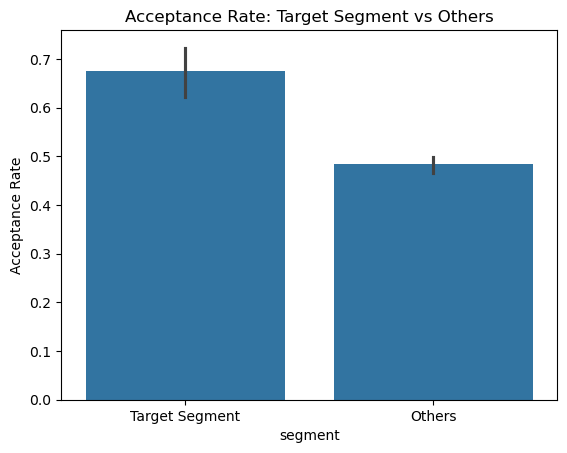

In [128]:
#Plotting the acceptance of this target segment vs Others customers for visul understanding

sns.barplot(data=data4, x="segment", y="Y")

plt.title("Acceptance Rate: Target Segment vs Others")
plt.ylabel("Acceptance Rate")
plt.show()

# The above analysis shows that the acceptance rate is high for the "Coffee House" coupon customers, if they are offered at 10AM time segment (which is early morning until 10am), when they are commuting with friends and to an non urgent place
